# Demand Forecasting Module (Multi-Product)

This notebook generates **14-day demand forecasts for every product (SKU)**.
It uses:

- Baseline models (Naive, MA7)
- ARIMA(1,1,1) model
- Multi-product forecasting loop
- Forecast export for the reorder system and dashboard

All forecasting logic is implemented inside:

`src/forecasting.py`

In [1]:
# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import sys
import os

sys.path.append(os.path.abspath("../src"))

from forecasting import (
    forecast_all_products,
    save_forecast_results
)

## Load Daily Demand Data

This data was created in the EDA notebook.
It contains daily aggregated demand per product.

In [2]:
daily_demand = pd.read_csv("../data/processed/daily_demand.csv")
daily_demand["order date (DateOrders)"] = pd.to_datetime(
    daily_demand["order date (DateOrders)"]
)

daily_demand.head()

,order date (DateOrders),Product Name,Order Item Quantity
0,2015-01-01,Bridgestone e6 Straight Distance NFL San Dieg,3
1,2015-01-01,Diamondback Women's Serene Classic Comfort Bi,10
2,2015-01-01,Field & Stream Sportsman 16 Gun Fire Safe,7
3,2015-01-01,Glove It Imperial Golf Towel,5
4,2015-01-01,Glove It Urban Brick Golf Towel,5


## Multi-Product Forecasting

For each product:

1. Build continuous time series  
2. Train/test split (80/20)  
3. Run Naive + MA7 + ARIMA(1,1,1)  
4. Generate 14-day forecast  
5. Store results in a single table  

All logic is executed through:

`forecast_all_products(daily_demand)`

In [3]:
forecast_results_df = forecast_all_products(daily_demand)

print("Total Products Forecasted:", forecast_results_df["Product Name"].nunique())
forecast_results_df.head()

Total Products Forecasted: 105


,Date,Product Name,ARIMA
0,2017-04-22,Bridgestone e6 Straight Distance NFL San Dieg,0.248575
1,2017-04-23,Bridgestone e6 Straight Distance NFL San Dieg,0.476748
2,2017-04-24,Bridgestone e6 Straight Distance NFL San Dieg,0.462870
3,2017-04-25,Bridgestone e6 Straight Distance NFL San Dieg,0.463714
4,2017-04-26,Bridgestone e6 Straight Distance NFL San Dieg,0.463663


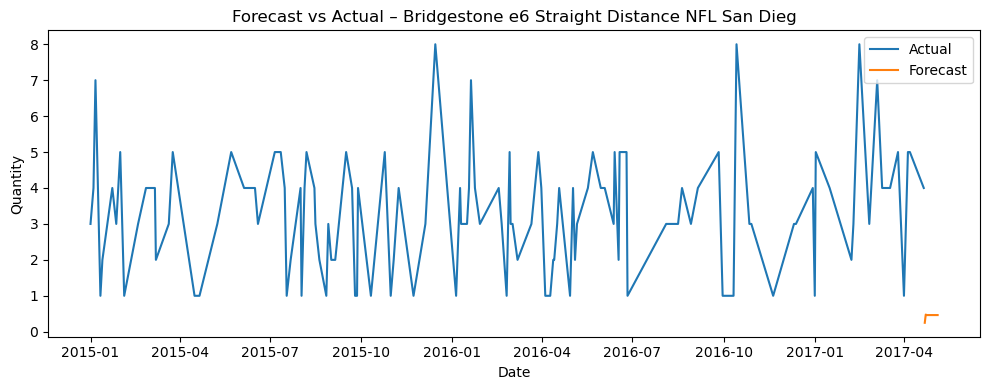

In [4]:
# Forecast Comparison Image (Actual vs ARIMA)

sample_product = forecast_results_df["Product Name"].iloc[0]

# Historical data
hist_df = daily_demand[daily_demand["Product Name"] == sample_product]
hist_df = hist_df.sort_values("order date (DateOrders)")

# Forecast data
fcast_df = forecast_results_df[forecast_results_df["Product Name"] == sample_product]

plt.figure(figsize=(10,4))

# Actual demand
plt.plot(hist_df["order date (DateOrders)"], 
         hist_df["Order Item Quantity"], 
         label="Actual")

# Forecast
plt.plot(fcast_df["Date"], 
         fcast_df["ARIMA"], 
         label="Forecast")

plt.title(f"Forecast vs Actual – {sample_product}")
plt.xlabel("Date")
plt.ylabel("Quantity")
plt.legend()
plt.tight_layout()

# SAVE IMAGE
plt.savefig("../outputs/figures/forecast_comparison.png")

plt.show()

## Save Forecast Results

This table is required for:

- 03_reorder_system.ipynb  
- Streamlit Inventory Dashboard  

In [5]:
save_forecast_results(
    forecast_results_df,
    "../outputs/tables/forecast_results.csv"
)

forecast_results_df.sample(5)

,Date,Product Name,ARIMA
1461,2018-02-06,Summer dresses,31.317406
1454,2018-02-13,Fighting video games,2.492438
1104,2017-09-24,Merrell Women's Grassbow Sport Hiking Shoe,0.626257
283,2017-04-17,TYR Boys' Team Digi Jammer,0.437940
731,2017-04-10,Team Golf St. Louis Cardinals Putter Grip,0.484938
